# Đánh giá 4 Cấu hình LLM × RAG

Chạy từ **cùng thư mục** với `finetune_qwen3_4b.ipynb` trên máy lab.

| | LLM gốc | LLM fine-tuned |
|---|---|---|
| **Không RAG** | **A** | **C** |
| **Có RAG** (Hybrid+Rerank, top-5) | **B** | **D** |

**Metrics**: BLEU · ROUGE-L · BERTScore-F1 · EM · METEOR · Recall@5  
**Dữ liệu**: `qa_dataset_clean.json`, lọc `split=test`  
**Retrieval**: Dense (`AITeamVN/Vietnamese_Embedding_v2`) + BM25 → RRF → Rerank (`BAAI/bge-reranker-v2-m3`)

In [1]:
# Chạy một lần nếu chưa cài
!pip -q install sacrebleu rouge-score bert-score pyvi rank-bm25 faiss-cpu underthesea nltk

In [2]:
from __future__ import annotations

import gc, json, os, re, unicodedata
from collections import defaultdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('DEVICE:', DEVICE)

DEVICE: cuda


/home/urlab/miniconda3/envs/uav_ai/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Cấu hình

Tất cả đường dẫn dùng **relative path** giống `finetune_qwen3_4b.ipynb` —  
chạy notebook này từ **cùng thư mục** (CWD thực tế trên lab: `/media/urlab/KINGSTON/nlp/`).

In [3]:
# ============================================================
# HF cache — giống hệt finetune_qwen3_4b.ipynb
# ============================================================
HF_CACHE_DIR = Path('hf_cache')
HF_CACHE_DIR.mkdir(parents=True, exist_ok=True)
HF_CACHE = str(HF_CACHE_DIR)

os.environ['HF_HOME']               = HF_CACHE
os.environ['TRANSFORMERS_CACHE']    = HF_CACHE
os.environ['HF_DATASETS_CACHE']     = HF_CACHE
os.environ['HUGGINGFACE_HUB_CACHE'] = HF_CACHE
os.environ['HF_HUB_CACHE']          = HF_CACHE

# ============================================================
# LLM — giống hệt finetune_qwen3_4b.ipynb
# ============================================================
# Base model: tải từ HF Hub, weights cache tại hf_cache/
MODEL_ID = 'Qwen/Qwen3-4B-Instruct-2507'

# LoRA adapter: output của trainer.save_model('qwen3-4b-qlora-jd/best')
# Cấu trúc sau khi train:
#   qwen3-4b-qlora-jd/
#   ├── best/               ← adapter_config.json + adapter_model.safetensors + tokenizer
#   ├── checkpoint-{N}/     ← step checkpoint (save_steps=100, save_total_limit=2)
#   └── checkpoint-{M}/
ADAPTER_PATH = 'qwen3-4b-qlora-jd/best'

# ============================================================
# Dữ liệu — relative path, cùng CWD với notebook
# ============================================================
DATA_DIR      = Path('data')               # data/train.jsonl, val.jsonl, test.jsonl
QA_CLEAN_PATH = Path('qa_dataset_clean.json')
JD_JSON_PATH  = Path('jd_full_text.json')
JD_EMB_PATH   = Path('jd_embeddings.npz')

# ============================================================
# Output
# ============================================================
OUTPUT_DIR = Path('4config_eval')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# Retrieval config (từ hybrid_retrieval_rerank_eval.ipynb)
# ============================================================
DENSE_MODEL_ID    = 'AITeamVN/Vietnamese_Embedding_v2'
RERANKER_MODEL_ID = 'BAAI/bge-reranker-v2-m3'
TOP_K          = 5      # Recall@5; số JD đưa vào context RAG
DENSE_TOP_K    = 50
BM25_TOP_K     = 50
FUSION_TOP_K   = 50
RRF_K          = 60
BATCH_EMBED    = 16
MAX_LEN_EMBED  = 512
MAX_LEN_RERANK = 1024

# ============================================================
# Inference config — giống finetune_qwen3_4b.ipynb
# ============================================================
MAX_NEW_TOKENS = 256
MAX_NEW_TOKENS_RAG = 128
MAX_NEW_TOKENS_RAG_FT = 64
MAX_INPUT_TOKENS = 1536
MAX_INPUT_TOKENS_FT_RAG = 1024
EVAL_SPLIT     = 'train'
SAMPLE_RATIO   = 0.10
SAMPLE_SEED    = 42

# --- Kiểm tra file ---
print(f'CWD           : {Path(".").resolve()}')
print(f'HF cache      : {HF_CACHE_DIR.resolve()}')
print(f'MODEL_ID      : {MODEL_ID}')
print(f'ADAPTER_PATH  : {Path(ADAPTER_PATH).resolve()}')
print(f'  adapter OK  : {Path(ADAPTER_PATH).exists()}')
for name, p in [('QA_CLEAN', QA_CLEAN_PATH), ('JD_JSON', JD_JSON_PATH),
                ('JD_EMB', JD_EMB_PATH), ('DATA_DIR', DATA_DIR)]:
    print(f'  {name:10s}: {p.resolve()}  ["OK" if p.exists() else "MISSING"]')


CWD           : /media/urlab/KINGSTON/nlp
HF cache      : /media/urlab/KINGSTON/nlp/hf_cache
MODEL_ID      : Qwen/Qwen3-4B-Instruct-2507
ADAPTER_PATH  : /media/urlab/KINGSTON/nlp/qwen3-4b-qlora-jd/best
  adapter OK  : True
  QA_CLEAN  : /media/urlab/KINGSTON/nlp/qa_dataset_clean.json  ["OK" if p.exists() else "MISSING"]
  JD_JSON   : /media/urlab/KINGSTON/nlp/jd_full_text.json  ["OK" if p.exists() else "MISSING"]
  JD_EMB    : /media/urlab/KINGSTON/nlp/jd_embeddings.npz  ["OK" if p.exists() else "MISSING"]
  DATA_DIR  : /media/urlab/KINGSTON/nlp/data  ["OK" if p.exists() else "MISSING"]


## 2. Load QA dataset (`qa_dataset_clean.json`, split=test)

In [4]:
import random

PLACEHOLDER_ANSWERS   = {'...', 'nội dung câu trả lời thực ở đây', ''}
PLACEHOLDER_QUESTIONS = {'...', ''}


def _norm(s: str) -> str:
    s = unicodedata.normalize('NFC', s or '')
    return re.sub(r'\s+', ' ', s).strip()


def parse_user_msg(user_content: str) -> Tuple[str, Optional[str]]:
    """Tách (question, candidate_profile) từ user message."""
    q_match = re.search(r'Câu hỏi:\s*(.+)', user_content, re.DOTALL)
    question = q_match.group(1).strip() if q_match else user_content.strip()

    p_match = re.search(
        r'Hồ sơ ứng viên:\s*(.+?)(?=\n\nCâu hỏi:)',
        user_content, re.DOTALL
    )
    profile = p_match.group(1).strip() if p_match else None
    return question, profile


def is_valid_item(item: dict) -> bool:
    msgs = item.get('messages', [])
    asst = next((m for m in msgs if m['role'] == 'assistant'), None)
    if not asst or asst['content'].strip() in PLACEHOLDER_ANSWERS:
        return False
    user = next((m for m in msgs if m['role'] == 'user'), None)
    if not user:
        return False
    q, _ = parse_user_msg(user['content'])
    return q not in PLACEHOLDER_QUESTIONS


with QA_CLEAN_PATH.open('r', encoding='utf-8') as f:
    qa_all = json.load(f)

test_items = [
    it for it in qa_all
    if str(it.get('split', '')).lower() == EVAL_SPLIT and is_valid_item(it)
]

if SAMPLE_RATIO < 1.0 and test_items:
    rng = random.Random(SAMPLE_SEED)
    sample_size = max(1, int(len(test_items) * SAMPLE_RATIO))
    test_items = rng.sample(test_items, sample_size)

print(f'Total in qa_dataset_clean : {len(qa_all)}')
print(f'{EVAL_SPLIT} split (valid)   : {len(test_items)}')
print(f'Sample ratio             : {SAMPLE_RATIO:.2f}  (seed={SAMPLE_SEED})')

if test_items:
    s = test_items[0]
    u = next(m for m in s['messages'] if m['role'] == 'user')
    q, prof = parse_user_msg(u['content'])
    print('\n--- Sample ---')
    print('id      :', s['id'])
    print('type    :', s.get('type'))
    print('jd_ids  :', s.get('_meta', {}).get('jd_ids'))
    print('question:', q[:120])
    print('profile :', (prof or '')[:80])


Total in qa_dataset_clean : 696
train split (valid)   : 64
Sample ratio             : 0.10  (seed=42)

--- Sample ---
id      : QA-0160
type    : t1
jd_ids  : ['JD-0722']
question: Tôi cần những kỹ năng gì để ứng tuyển vị trí Chuyên viên tư vấn tín dụng bán lẻ?
profile : 


## 3. Load JD corpus + build BM25 + load Dense encoder & Reranker

Dùng đúng config từ `hybrid_retrieval_rerank_eval.ipynb`:  
`AITeamVN/Vietnamese_Embedding_v2` · `BAAI/bge-reranker-v2-m3` · RRF k=60

In [5]:
# jd_full_text.json: [{jd_id, company, title, city, text}, ...]
with JD_JSON_PATH.open('r', encoding='utf-8') as f:
    jd_raw = json.load(f)

jd_by_id: Dict[str, dict] = {}
for jd in (jd_raw if isinstance(jd_raw, list) else []):
    jid = str(jd.get('jd_id', '')).strip()
    if jid:
        jd_by_id[jid] = jd

# jd_embeddings.npz: embeddings, jd_ids, texts
emb_npz   = np.load(JD_EMB_PATH, allow_pickle=True)
doc_embs  = emb_npz['embeddings'].astype(np.float32)
doc_embs /= np.linalg.norm(doc_embs, axis=1, keepdims=True) + 1e-12
doc_ids   = [str(x) for x in emb_npz['jd_ids']]
doc_texts = [_norm(str(x)) for x in emb_npz['texts']]
doc_id_to_idx = {d: i for i, d in enumerate(doc_ids)}

print(f'JD corpus : {len(doc_ids)} docs  |  embedding shape: {doc_embs.shape}')
print(f'jd_by_id  : {len(jd_by_id)} entries')

JD corpus : 580 docs  |  embedding shape: (580, 1024)
jd_by_id  : 580 entries


In [6]:
from rank_bm25 import BM25Okapi

VN_TOKENIZER = 'regex'
try:
    from underthesea import word_tokenize as _uts
    def vi_tokenize(text: str) -> List[str]:
        return [t for t in _uts(text, format='text').split() if t]
    VN_TOKENIZER = 'underthesea'
except Exception:
    try:
        from pyvi import ViTokenizer as _vt
        def vi_tokenize(text: str) -> List[str]:
            return [t.replace('_', ' ') for t in _vt.tokenize(text).split() if t]
        VN_TOKENIZER = 'pyvi'
    except Exception:
        _RE = re.compile(r'\w+', re.UNICODE)
        def vi_tokenize(text: str) -> List[str]:
            return _RE.findall(text.lower())

def bm25_tokenize(text: str) -> List[str]:
    return vi_tokenize(_norm(text).lower())

bm25_index = BM25Okapi([bm25_tokenize(t) for t in doc_texts])
print(f'BM25 ready — tokenizer: {VN_TOKENIZER},  {len(doc_ids)} docs')

BM25 ready — tokenizer: underthesea,  580 docs


In [7]:
import faiss
from transformers import AutoModel, AutoModelForSequenceClassification, AutoTokenizer as _ATokenizer

dense_tokenizer = _ATokenizer.from_pretrained(DENSE_MODEL_ID, cache_dir=HF_CACHE)
dense_encoder   = AutoModel.from_pretrained(DENSE_MODEL_ID, cache_dir=HF_CACHE).to(DEVICE).eval()

rerank_tokenizer = _ATokenizer.from_pretrained(RERANKER_MODEL_ID, cache_dir=HF_CACHE)
rerank_model     = AutoModelForSequenceClassification.from_pretrained(
    RERANKER_MODEL_ID, cache_dir=HF_CACHE
).to(DEVICE).eval()

faiss_index = faiss.IndexFlatIP(doc_embs.shape[1])
faiss_index.add(doc_embs)

print('Dense encoder :', DENSE_MODEL_ID)
print('Reranker      :', RERANKER_MODEL_ID)
print('FAISS ntotal  :', faiss_index.ntotal)

Loading weights: 100%|██████████| 393/393 [00:00<00:00, 27182.29it/s]


Dense encoder : AITeamVN/Vietnamese_Embedding_v2
Reranker      : BAAI/bge-reranker-v2-m3
FAISS ntotal  : 580


## 4. Hàm retrieval (Dense + BM25 → RRF → Rerank)

In [8]:
@torch.no_grad()
def encode_queries(texts: List[str]) -> np.ndarray:
    all_vecs = []
    for i in range(0, len(texts), BATCH_EMBED):
        batch = [_norm(t) for t in texts[i : i + BATCH_EMBED]]
        enc   = dense_tokenizer(
            batch, padding=True, truncation=True,
            max_length=MAX_LEN_EMBED, return_tensors='pt'
        ).to(DEVICE)
        out  = dense_encoder(**enc, return_dict=True)
        cls  = F.normalize(out.last_hidden_state[:, 0], p=2, dim=-1)
        all_vecs.append(cls.cpu().numpy().astype(np.float32))
    return np.concatenate(all_vecs, axis=0)


def dense_search(query: str, top_k: int = DENSE_TOP_K) -> List[Tuple[str, float, int]]:
    q = encode_queries([query])
    scores, idx = faiss_index.search(q, top_k)
    return [(doc_ids[i], float(scores[0][r]), r + 1) for r, i in enumerate(idx[0])]


def bm25_search(query: str, top_k: int = BM25_TOP_K) -> List[Tuple[str, float, int]]:
    toks   = bm25_tokenize(query)
    scores = bm25_index.get_scores(toks)
    idx    = np.argpartition(-scores, top_k - 1)[:top_k]
    idx    = idx[np.argsort(-scores[idx])]
    return [(doc_ids[i], float(scores[i]), rank + 1) for rank, i in enumerate(idx)]


def rrf_fusion(
    result_lists: List[List[Tuple[str, float, int]]], k: int = RRF_K
) -> List[Tuple[str, float]]:
    fused: Dict[str, float] = defaultdict(float)
    for results in result_lists:
        for doc_id, _, rank in results:
            fused[doc_id] += 1.0 / (k + rank)
    return sorted(fused.items(), key=lambda x: x[1], reverse=True)


@torch.no_grad()
def rerank(query: str, candidate_ids: List[str], top_k: int = TOP_K) -> List[str]:
    query  = _norm(query)
    valid  = [d for d in candidate_ids if d in doc_id_to_idx]
    pairs  = [[query, doc_texts[doc_id_to_idx[d]]] for d in valid]
    enc    = rerank_tokenizer(
        pairs, padding=True, truncation=True,
        max_length=MAX_LEN_RERANK, return_tensors='pt'
    ).to(DEVICE)
    scores = rerank_model(**enc, return_dict=True).logits.view(-1).cpu().numpy()
    return [valid[i] for i in np.argsort(-scores)][:top_k]


def hybrid_rerank(query: str, top_k: int = TOP_K) -> List[str]:
    """Hybrid Dense+BM25 → RRF → Rerank → top_k doc ids."""
    fused = rrf_fusion([
        dense_search(query, top_k=DENSE_TOP_K),
        bm25_search(query,  top_k=BM25_TOP_K),
    ])
    candidates = [d for d, _ in fused[:FUSION_TOP_K]]
    return rerank(query, candidates, top_k=top_k)


# Smoke test
print('Demo:', hybrid_rerank('Python backend 3 năm kinh nghiệm', top_k=3))

Demo: ['JD-0001', 'JD-0113', 'JD-0352']


## 5. Pre-compute retrieval cho toàn bộ test set (cache, có thể resume)

In [9]:
RETRIEVAL_CACHE_PATH = OUTPUT_DIR / 'retrieval_cache.json'

if RETRIEVAL_CACHE_PATH.exists():
    with RETRIEVAL_CACHE_PATH.open('r', encoding='utf-8') as f:
        retrieval_cache: Dict[str, List[str]] = json.load(f)
    print(f'Loaded cache: {len(retrieval_cache)} entries')
else:
    retrieval_cache = {}

missing = [it for it in test_items if it['id'] not in retrieval_cache]
print(f'Items to retrieve: {len(missing)}')

for item in tqdm(missing, desc='Retrieving'):
    u = next(m for m in item['messages'] if m['role'] == 'user')
    q, _ = parse_user_msg(u['content'])
    retrieval_cache[item['id']] = hybrid_rerank(q, top_k=TOP_K)

with RETRIEVAL_CACHE_PATH.open('w', encoding='utf-8') as f:
    json.dump(retrieval_cache, f, ensure_ascii=False, indent=2)
print(f'Cache saved → {RETRIEVAL_CACHE_PATH}')

# Recall@5 (không cần LLM)
recall5_scores = []
for item in test_items:
    gt  = set(str(x) for x in item.get('_meta', {}).get('jd_ids', []))
    ret = set(retrieval_cache.get(item['id'], []))
    if gt:
        recall5_scores.append(len(gt & ret) / len(gt))

recall5 = 100.0 * sum(recall5_scores) / len(recall5_scores) if recall5_scores else 0.0
print(f'\nRecall@{TOP_K} (hybrid+rerank) = {recall5:.2f}%  ({len(recall5_scores)} items có gt_jd_ids)')

Loaded cache: 64 entries
Items to retrieve: 0


Retrieving: 0it [00:00, ?it/s]

Cache saved → 4config_eval/retrieval_cache.json

Recall@5 (hybrid+rerank) = 71.24%  (64 items có gt_jd_ids)


## 6. Prompt template

Format **bám sát data train** (`data/train.jsonl`):
- System prompt: y hệt `messages[0].content` trong train
- RAG: thêm `Thông tin tuyển dụng:\n[JD-XXXX]\n{text}` — dùng `jd_full_text.json`
- No RAG: chỉ `Hồ sơ ứng viên` (nếu có) + `Câu hỏi`

In [10]:
# Lấy system prompt chính xác từ file train (tránh gõ sai)
_train_sample = None
_train_path = DATA_DIR / 'train.jsonl'
if _train_path.exists():
    with _train_path.open('r', encoding='utf-8') as _f:
        _train_sample = json.loads(_f.readline())
    SYSTEM_PROMPT = next(
        m['content'] for m in _train_sample['messages'] if m['role'] == 'system'
    )
else:
    SYSTEM_PROMPT = (
        'Trợ lý tư vấn việc làm IT tại Việt Nam. '
        'Trả lời dựa trên thông tin tuyển dụng được cung cấp, chính xác và ngắn gọn. '
        'Không dùng \'em\' hay \'bạn\' trong câu trả lời — viết trung lập như thông tin tra cứu. '
        'Nếu thông tin không có trong dữ liệu, nói rõ thay vì đoán.'
    )

print('System prompt:', SYSTEM_PROMPT[:120], '...')


def build_jd_context(jd_ids: List[str]) -> str:
    """Build context block theo format multi-JD của training data."""
    blocks = []
    for jd_id in jd_ids:
        jd = jd_by_id.get(jd_id)
        if jd:
            text = jd.get('text', '')
        else:
            idx  = doc_id_to_idx.get(jd_id)
            text = doc_texts[idx] if idx is not None else ''
        if text:
            blocks.append(f'[{jd_id}]\n{text}')
    return '\n\n'.join(blocks)


def build_messages(
    question: str,
    profile: Optional[str] = None,
    jd_ids: Optional[List[str]] = None,
) -> List[Dict]:
    parts = []
    if jd_ids:
        ctx = build_jd_context(jd_ids)
        if ctx:
            parts.append(f'Thông tin tuyển dụng:\n{ctx}')
    if profile:
        parts.append(f'Hồ sơ ứng viên: {profile}')
    parts.append(f'Câu hỏi: {question}')
    return [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user',   'content': '\n\n'.join(parts)},
    ]


# Ví dụ
_it = test_items[0]
_u  = next(m for m in _it['messages'] if m['role'] == 'user')
_q, _p = parse_user_msg(_u['content'])
_ids   = retrieval_cache.get(_it['id'], [])
print('\n=== No-RAG user msg ===')
print(build_messages(_q, _p)[-1]['content'][:300])
print('\n=== RAG user msg (top-5) ===')
print(build_messages(_q, _p, _ids)[-1]['content'][:500])

System prompt: Trợ lý tư vấn việc làm IT tại Việt Nam. Trả lời dựa trên thông tin tuyển dụng được cung cấp, chính xác và ngắn gọn. Khôn ...

=== No-RAG user msg ===
Câu hỏi: Tôi cần những kỹ năng gì để ứng tuyển vị trí Chuyên viên tư vấn tín dụng bán lẻ?

=== RAG user msg (top-5) ===
Thông tin tuyển dụng:
[JD-0753]
Công ty Ngân hàng TMCP Hàng Hải Việt Nam (MSB) tuyển Chuyên viên Tư vấn Tín dụng Bán lẻ - RB - MSB - 3V010, level Junior, Middle, tại Hà Nội. Kinh nghiệm: 06 tháng. Kỹ năng bắt buộc: Tốt nghiệp Cao đẳng trở lên, Tiếng Anh cơ bản (Toeic 200-300), Thành thạo tin học văn phòng, Tối thiểu 6 tháng kinh nghiệm bán sản phẩm tín dụng hoặc 2 năm kinh nghiệm trong lĩnh vực tài chính/ngân hàng, Am hiểu sản phẩm tín dụng cá nhân và quy trình ngân hàng, Khả năng phân tích tài 


## 7. Load LLM + hàm generate

BNB config và cách load **giống hệt** `finetune_qwen3_4b.ipynb`.  
Load Base → gen A+B → unload.  Load FT → gen C+D → unload.

In [11]:
from transformers import AutoTokenizer as _AT, AutoModelForCausalLM as _AM, BitsAndBytesConfig
from peft import PeftModel

# Same bnb config as finetune notebook

def _bnb_config(enable_cpu_offload: bool = False) -> BitsAndBytesConfig:
    return BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
        llm_int8_enable_fp32_cpu_offload=enable_cpu_offload,
    )


def _max_memory():
    if torch.cuda.is_available():
        total_gb = int(torch.cuda.get_device_properties(0).total_memory / (1024**3))
        gpu_gb = max(total_gb - 1, 1)
        return {0: f"{gpu_gb}GiB", "cpu": "48GiB"}
    return {"cpu": "48GiB"}


def _load_tokenizer():
    tok = _AT.from_pretrained(MODEL_ID, trust_remote_code=True, cache_dir=HF_CACHE)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    tok.padding_side = 'right'   # same as finetune notebook
    return tok


def _load_base_model_only():
    try:
        return _AM.from_pretrained(
            MODEL_ID,
            quantization_config=_bnb_config(False),
            device_map='auto',
            trust_remote_code=True,
            torch_dtype=torch.bfloat16,  # deprecated but works
            cache_dir=HF_CACHE,
        )
    except ValueError as e:
        if 'llm_int8_enable_fp32_cpu_offload' not in str(e):
            raise
        return _AM.from_pretrained(
            MODEL_ID,
            quantization_config=_bnb_config(True),
            device_map='auto',
            max_memory=_max_memory(),
            trust_remote_code=True,
            torch_dtype=torch.bfloat16,
            cache_dir=HF_CACHE,
        )


def load_base_model():
    tok = _load_tokenizer()
    mdl = _load_base_model_only()
    mdl.config.use_cache = True
    return tok, mdl


def load_ft_model():
    """Load base + PeftModel.from_pretrained."""
    if not Path(ADAPTER_PATH).exists():
        raise FileNotFoundError(
            f'Adapter không tìm thấy: {Path(ADAPTER_PATH).resolve()}\n'
            f'Chạy finetune_qwen3_4b.ipynb trước (trainer.save_model \'{ADAPTER_PATH}\').'
        )
    tok = _load_tokenizer()
    base = _load_base_model_only()
    ft = PeftModel.from_pretrained(base, ADAPTER_PATH)
    ft.config.use_cache = True
    return tok, ft


def free_model(*models):
    for m in models:
        del m
    gc.collect()
    torch.cuda.empty_cache()


@torch.inference_mode()
def generate_predictions(
    model, tokenizer,
    items: List[dict],
    use_rag: bool,
    out_path: Path,
    desc: str = '',
    max_new_tokens: int = MAX_NEW_TOKENS,
    max_input_tokens: Optional[int] = None,
    use_cache: bool = True,
) -> List[Dict]:
    """Generate for all items. Supports resume from existing JSONL."""
    model.eval()

    # Resume: load already done
    done: Dict[str, str] = {}
    if out_path.exists():
        with out_path.open('r', encoding='utf-8') as f:
            for line in f:
                obj = json.loads(line)
                done[obj['id']] = obj['pred']
        if done:
            print(f'  Resume: {len(done)} already done')

    prev_use_cache = getattr(model.config, 'use_cache', None)
    if prev_use_cache is not None:
        model.config.use_cache = use_cache

    try:
        results = []
        with out_path.open('a', encoding='utf-8') as f_out:
            for item in tqdm(items, desc=desc):
                iid  = item['id']
                msgs = item['messages']
                user = next(m for m in msgs if m['role'] == 'user')
                ref  = next(m for m in msgs if m['role'] == 'assistant')['content'].strip()

                if iid in done:
                    results.append({'id': iid, 'pred': done[iid], 'reference': ref})
                    continue

                question, profile = parse_user_msg(user['content'])
                jd_ids   = retrieval_cache.get(iid, []) if use_rag else None
                prompt   = build_messages(question, profile, jd_ids)

                ct_kwargs = dict(
                    add_generation_prompt=True,
                    tokenize=True,
                    return_dict=True,
                    return_tensors='pt',
                )
                if max_input_tokens is not None:
                    ct_kwargs['truncation'] = True
                    ct_kwargs['max_length'] = max_input_tokens

                inputs = tokenizer.apply_chat_template(prompt, **ct_kwargs).to(model.device)

                out = model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    do_sample=False,
                    pad_token_id=tokenizer.pad_token_id,
                    use_cache=use_cache,
                )
                pred = tokenizer.decode(
                    out[0][inputs['input_ids'].shape[-1]:],
                    skip_special_tokens=True
                ).strip()

                results.append({'id': iid, 'pred': pred, 'reference': ref})
                f_out.write(json.dumps(
                    {'id': iid, 'pred': pred, 'reference': ref},
                    ensure_ascii=False
                ) + '\n')

        return results
    finally:
        if prev_use_cache is not None:
            model.config.use_cache = prev_use_cache


print('LLM helpers ready.')


LLM helpers ready.


## 8. Generate — Base model (Config A: No RAG, Config B: RAG)

In [12]:
print('Loading BASE model (Qwen3-4B-Instruct-2507, 4-bit)...')
tok_base, mdl_base = load_base_model()
print('Base model loaded.')

preds_A = generate_predictions(
    mdl_base, tok_base, test_items,
    use_rag=False,
    out_path=OUTPUT_DIR / 'pred_A_base_norag.jsonl',
    desc='A — Base, No RAG',
)

preds_B = generate_predictions(
    mdl_base, tok_base, test_items,
    use_rag=True,
    out_path=OUTPUT_DIR / 'pred_B_base_rag.jsonl',
    desc='B — Base, RAG (top-5)',
    max_new_tokens=MAX_NEW_TOKENS_RAG,
    max_input_tokens=MAX_INPUT_TOKENS,
    use_cache=False,
)

free_model(mdl_base)
print('Base model freed.')


Loading BASE model (Qwen3-4B-Instruct-2507, 4-bit)...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 538.91it/s]


Base model loaded.
  Resume: 64 already done


A — Base, No RAG: 100%|██████████| 64/64 [00:00<00:00, 458864.03it/s]


  Resume: 64 already done


B — Base, RAG (top-5): 100%|██████████| 64/64 [00:00<00:00, 945195.27it/s]

Base model freed.


## 9. Generate — Fine-tuned model (Config C: No RAG, Config D: RAG)

Adapter path: `qwen3-4b-qlora-jd/best`  
(output của `trainer.save_model('qwen3-4b-qlora-jd/best')` trong `finetune_qwen3_4b.ipynb`)

In [13]:
print(f'Loading FINE-TUNED model (base + LoRA adapter từ {ADAPTER_PATH})...')
tok_ft, mdl_ft = load_ft_model()
print('FT model loaded.')

preds_C = generate_predictions(
    mdl_ft, tok_ft, test_items,
    use_rag=False,
    out_path=OUTPUT_DIR / 'pred_C_ft_norag.jsonl',
    desc='C — FT, No RAG',
)

del preds_C
if torch.cuda.is_available():
    torch.cuda.empty_cache()

t_preds_D = generate_predictions(
    mdl_ft, tok_ft, test_items,
    use_rag=True,
    out_path=OUTPUT_DIR / 'pred_D_ft_rag.jsonl',
    desc='D — FT, RAG (top-5)',
    max_new_tokens=MAX_NEW_TOKENS_RAG_FT,
    max_input_tokens=MAX_INPUT_TOKENS_FT_RAG,
    use_cache=False,
)

free_model(mdl_ft)
print('FT model freed.')


Loading FINE-TUNED model (base + LoRA adapter từ qwen3-4b-qlora-jd/best)...


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 542.76it/s]


FT model loaded.
  Resume: 64 already done


C — FT, No RAG: 100%|██████████| 64/64 [00:00<00:00, 484540.53it/s]


  Resume: 64 already done


D — FT, RAG (top-5): 100%|██████████| 64/64 [00:00<00:00, 865920.83it/s]


FT model freed.


## 10. Tính metrics

Giống hệt `evaluate_pair` trong `finetune_qwen3_4b.ipynb`:  
BLEU (`intl`) · ROUGE-L (ViTokenizer) · BERTScore-F1 (`xlm-roberta-large`) · EM · METEOR

In [14]:
import torch
import sacrebleu
from rouge_score import rouge_scorer as _rs
from bert_score import score as _bert_score
from pyvi import ViTokenizer as _vi_tok

try:
    import nltk
    from nltk.translate.meteor_score import meteor_score as _meteor_fn
    _METEOR_OK = True
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
except Exception:
    _METEOR_OK = False
    print('METEOR unavailable (NLTK not found)')


def _to_vi_tokens(s: str) -> List[str]:
    return _vi_tok.tokenize(s).split()


def _bert_score_safe(preds: List[str], refs: List[str]) -> float:
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    try:
        _, _, F1 = _bert_score(
            preds, refs,
            model_type='xlm-roberta-large', lang='vi',
            rescale_with_baseline=False, batch_size=8, verbose=False,
            device=device,
        )
    except Exception as e:
        msg = str(e).lower()
        if 'out of memory' not in msg:
            raise
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        _, _, F1 = _bert_score(
            preds, refs,
            model_type='xlm-roberta-large', lang='vi',
            rescale_with_baseline=False, batch_size=2, verbose=False,
            device='cpu',
        )
    return 100.0 * F1.mean().item()


def compute_metrics(pred_records: List[Dict], label: str) -> Dict[str, float]:
    preds = [r['pred']      for r in pred_records]
    refs  = [r['reference'] for r in pred_records]

    bleu    = sacrebleu.corpus_bleu(preds, [refs], tokenize='intl').score

    rl_scorer = _rs.RougeScorer(['rougeL'], use_stemmer=False)
    rougeL = 100.0 * sum(
        rl_scorer.score(_vi_tok.tokenize(r), _vi_tok.tokenize(p))['rougeL'].fmeasure
        for p, r in zip(preds, refs)
    ) / max(len(preds), 1)

    bertscore = _bert_score_safe(preds, refs)

    def nrm(s): return re.sub(r'\s+', ' ', s.lower().strip())
    em = 100.0 * sum(nrm(p) == nrm(r) for p, r in zip(preds, refs)) / max(len(preds), 1)

    meteor = None
    if _METEOR_OK:
        try:
            meteor = 100.0 * sum(
                _meteor_fn([_to_vi_tokens(r)], _to_vi_tokens(p))
                for p, r in zip(preds, refs)
            ) / max(len(preds), 1)
        except Exception as e:
            print('METEOR error:', e)

    result = {
        'BLEU': round(bleu, 2),
        'ROUGE-L': round(rougeL, 2),
        'BERTScore-F1': round(bertscore, 2),
        'EM': round(em, 2),
        'METEOR': round(meteor, 2) if meteor is not None else None,
    }
    print(f'\n== {label} ==')
    for k, v in result.items():
        print(f'  {k:16s}: {v if v is not None else "N/A"}')
    return result


def load_jsonl(path: Path) -> List[Dict]:
    with path.open('r', encoding='utf-8') as f:
        return [json.loads(line) for line in f]


print('Metrics functions ready.')


Metrics functions ready.


In [15]:
CONFIGS = {
    'A — Base, No RAG':  OUTPUT_DIR / 'pred_A_base_norag.jsonl',
    'B — Base, RAG':     OUTPUT_DIR / 'pred_B_base_rag.jsonl',
    'C — FT,   No RAG': OUTPUT_DIR / 'pred_C_ft_norag.jsonl',
    'D — FT,   RAG':    OUTPUT_DIR / 'pred_D_ft_rag.jsonl',
}

all_metrics: Dict[str, Dict] = {}
for label, path in CONFIGS.items():
    if not path.exists():
        print(f'SKIP (file chưa có): {path}')
        continue
    all_metrics[label] = compute_metrics(load_jsonl(path), label)

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 25035.84it/s]
[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 391/391 [00:00<00:00, 32248.02it/s]
[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias  


== A — Base, No RAG ==
  BLEU            : 3.56
  ROUGE-L         : 28.78
  BERTScore-F1    : 86.25
  EM              : 0.0
  METEOR          : 20.59


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 27452.76it/s]
[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 391/391 [00:00<00:00, 23575.70it/s]
[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias  


== B — Base, RAG ==
  BLEU            : 7.48
  ROUGE-L         : 33.61
  BERTScore-F1    : 87.15
  EM              : 0.0
  METEOR          : 22.19


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 22370.08it/s]
[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 391/391 [00:00<00:00, 27555.62it/s]
[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias  


== C — FT,   No RAG ==
  BLEU            : 11.9
  ROUGE-L         : 35.41
  BERTScore-F1    : 89.28
  EM              : 0.0
  METEOR          : 25.81


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 24833.78it/s]
[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 391/391 [00:00<00:00, 25206.70it/s]
[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias  


== D — FT,   RAG ==
  BLEU            : 2.05
  ROUGE-L         : 25.8
  BERTScore-F1    : 85.71
  EM              : 0.0
  METEOR          : 9.25


## 11. Bảng tổng hợp + biểu đồ

In [8]:
import pandas as pd

ORDER = ['A — Base, No RAG', 'B — Base, RAG', 'C — FT,   No RAG', 'D — FT,   RAG']
csv_path = OUTPUT_DIR / 'eval_results_4config.csv'

if csv_path.exists():
    df = pd.read_csv(csv_path)
    print(f'Loaded → {csv_path}')
else:
    rows = []
    for label in ORDER:
        m = all_metrics.get(label, {})
        rows.append({
            'Config'           : label,
            'BLEU'             : m.get('BLEU'),
            'ROUGE-L'          : m.get('ROUGE-L'),
            'BERTScore-F1'     : m.get('BERTScore-F1'),
            'EM'               : m.get('EM'),
            'METEOR'           : m.get('METEOR'),
            f'Recall@{TOP_K}'  : round(recall5, 2) if ('RAG' in label and 'No RAG' not in label) else 'N/A',
        })
    df = pd.DataFrame(rows)
    df.to_csv(csv_path, index=False)
    print(f'Saved → {csv_path}')

print(df.to_string(index=False))


def _to_float(x):
    try:
        return float(x)
    except (TypeError, ValueError):
        return None


all_metrics_plot = {}
for _, row in df.iterrows():
    cfg = row.get('Config')
    if not isinstance(cfg, str):
        continue
    all_metrics_plot[cfg] = {
        'BLEU': _to_float(row.get('BLEU')),
        'ROUGE-L': _to_float(row.get('ROUGE-L')),
        'BERTScore-F1': _to_float(row.get('BERTScore-F1')),
        'EM': _to_float(row.get('EM')),
        'METEOR': _to_float(row.get('METEOR')),
    }


Loaded → 4config_eval/eval_results_4config.csv
          Config  BLEU  ROUGE-L  BERTScore-F1  EM  METEOR  Recall@5
A — Base, No RAG  5.81    34.59         89.49 0.0   24.72       NaN
   B — Base, RAG 12.34    43.75         91.50 0.0   30.35     69.41
C — FT,   No RAG 32.28    57.07         93.24 0.0   53.17       NaN
   D — FT,   RAG 46.95    68.26         95.67 0.0   63.96     69.41


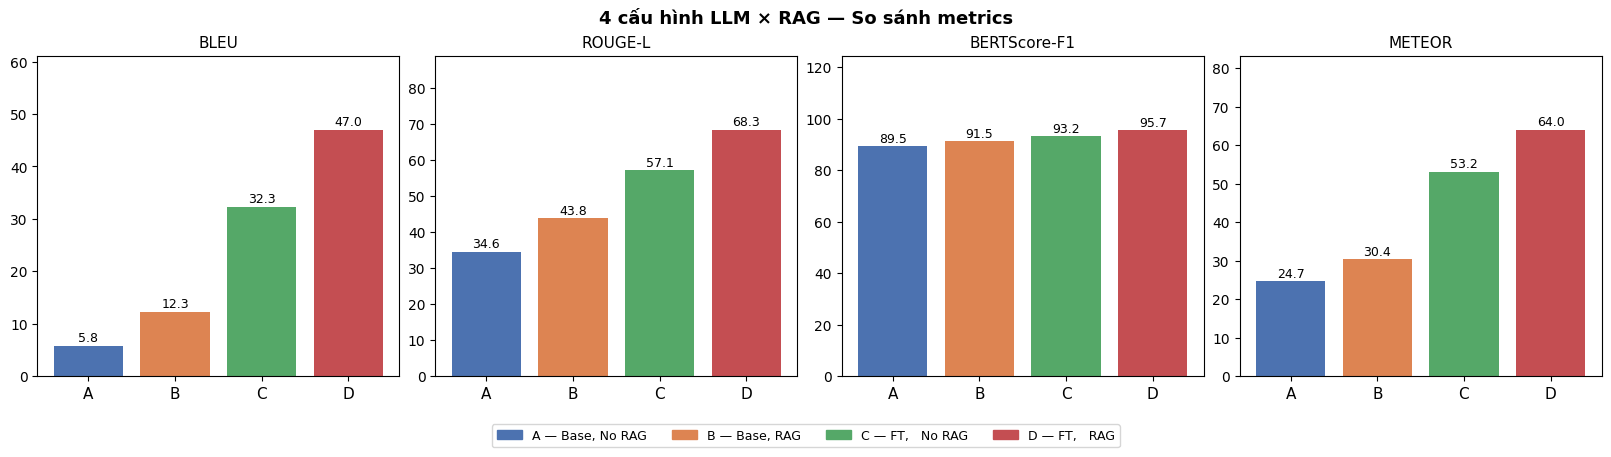

Plot saved → 4config_eval/eval_4config_plot.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

METRICS_PLOT = ['BLEU', 'ROUGE-L', 'BERTScore-F1', 'METEOR']
COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
labels_plot = [label for label in ORDER if label in all_metrics_plot]

fig, axes = plt.subplots(1, len(METRICS_PLOT), figsize=(16, 4), constrained_layout=True)
fig.suptitle('4 cấu hình LLM × RAG — So sánh metrics', fontsize=13, fontweight='bold')

for ax, metric in zip(axes, METRICS_PLOT):
    vals = []
    for label in labels_plot:
        v = all_metrics_plot[label].get(metric)
        vals.append(v if v is not None else 0.0)
    bars = ax.bar(range(len(labels_plot)), vals, color=COLORS[:len(labels_plot)])
    ax.set_title(metric, fontsize=11)
    ax.set_xticks(range(len(labels_plot)))
    ax.set_xticklabels([lb.split(' — ')[0] for lb in labels_plot], fontsize=11)
    ax.set_ylim(0, max(vals) * 1.3 if max(vals) > 0 else 1)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{v:.1f}', ha='center', va='bottom', fontsize=9)

patches = [mpatches.Patch(color=COLORS[i], label=labels_plot[i]) for i in range(len(labels_plot))]
fig.legend(handles=patches, loc='lower center', ncol=len(labels_plot),
           bbox_to_anchor=(0.5, -0.12), fontsize=9)

plot_path = OUTPUT_DIR / 'eval_4config_plot.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved → {plot_path}')


In [18]:
# Xem ví dụ định tính (3 câu đầu)
by_id: Dict[str, Dict] = defaultdict(dict)
for cfg_key, path in [('A', OUTPUT_DIR/'pred_A_base_norag.jsonl'),
                      ('B', OUTPUT_DIR/'pred_B_base_rag.jsonl'),
                      ('C', OUTPUT_DIR/'pred_C_ft_norag.jsonl'),
                      ('D', OUTPUT_DIR/'pred_D_ft_rag.jsonl')]:
    if path.exists():
        for rec in load_jsonl(path):
            by_id[rec['id']][cfg_key]      = rec['pred']
            by_id[rec['id']]['reference']  = rec['reference']

for item in test_items[:3]:
    iid  = item['id']
    u    = next(m for m in item['messages'] if m['role'] == 'user')
    q, _ = parse_user_msg(u['content'])
    print('=' * 72)
    print(f'ID       : {iid}')
    print(f'GT JDs   : {item.get("_meta", {}).get("jd_ids")}')
    print(f'Ret JDs  : {retrieval_cache.get(iid)}')
    print(f'Question : {q[:110]}')
    entry = by_id.get(iid, {})
    print(f'  Reference : {entry.get("reference", "")[:180]}')
    for cfg in ['A', 'B', 'C', 'D']:
        print(f'  Pred {cfg}     : {entry.get(cfg, "N/A")[:180]}')
    print()

ID       : QA-0160
GT JDs   : ['JD-0722']
Ret JDs  : ['JD-0753', 'JD-0722', 'JD-0739', 'JD-0706', 'JD-0336']
Question : Tôi cần những kỹ năng gì để ứng tuyển vị trí Chuyên viên tư vấn tín dụng bán lẻ?
  Reference : Yêu cầu bắt buộc bao gồm trình độ tốt nghiệp Cao đẳng trở lên và sử dụng thành thạo các phần mềm văn phòng. Các ứng viên ưu tiên có chuyên ngành Kinh tế, Tài chính, Ngân hàng hoặc 
  Pred A     : Vị trí Chuyên viên tư vấn tín dụng bán lẻ không thuộc lĩnh vực IT. Để ứng tuyển vị trí này, bạn cần có các kỹ năng sau:

- Kiến thức về tín dụng, quy trình thẩm định hồ sơ khách hà
  Pred B     : [JD-0337]
Công ty Ngân hàng TMCP Thịnh vượng và Phát triển (PGBank) tuyển CHUYÊN VIÊN PHÂN TÍCH TÍN DỤNG, level Middle, Senior, tại Hà Nội. Kinh nghiệm: 3 năm. Kỹ năng bắt buộc: Tố
  Pred C     : Vị trí này yêu cầu sự thân thiện, lịch sự và khả năng giao tiếp tốt để tiếp xúc khách hàng. Ứng viên cần có kiến thức về nghiệp vụ tín dụng và kỹ năng tư vấn bán hàng. Khả năng làm
  Pred D     : )